In [2]:
!pip install textblob wordcloud vaderSentiment

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 8.6 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 10.3 MB/s  0:00:00

   ---------------------------------------- 0/5 [regex]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5 [nltk]
   ---------------- ----------------------- 2/5

In [3]:
!python -m textblob.download_corpora

Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\brown.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\conll2000.zip.
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

In [5]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter

print("All libraries loaded!")

All libraries loaded!


In [7]:
np.random.seed(42)

In [8]:
positive_reviews = [
    "This product is amazing! Best purchase I've made this year.",
    "Absolutely love it. Works perfectly and arrived on time.",
    "Great quality for the price. Highly recommend to everyone.",
    "Exceeded my expectations. Five stars without hesitation!",
    "Fantastic product, will definitely buy again. So happy!",
    "The quality is outstanding and customer service was excellent.",
    "Perfect fit, exactly what I needed. Very satisfied with this.",
    "Incredible value for money. My whole family loves it.",
    "Superb quality and fast shipping. Couldn't be happier!",
    "This is exactly what I was looking for. Works like a charm.",
    "Wonderful product, easy to use and very well made.",
    "Best thing I've bought online. Totally worth every penny.",
    "Love the design and functionality. Really impressed!",
    "High quality material and great craftsmanship. Excellent!",
    "Super fast delivery and the product is even better in person.",
    "My expectations were exceeded. This is a premium product.",
    "Bought this as a gift and they absolutely loved it!",
    "Very durable and well-built. Should last for years.",
    "The color and size were perfect. Exactly as described.",
    "I've recommended this to all my friends. It's that good!",
    "Simple to set up and works flawlessly. Great purchase.",
    "Outstanding performance. Way better than the competition.",
    "The whole experience from ordering to delivery was smooth.",
    "Such a well-designed product. They really thought of everything.",
    "Been using it for a month now and still impressed daily.",
    "This brand never disappoints. Another great product from them.",
    "Comfortable, stylish, and affordable. What more could you want?",
    "Easy returns policy too, but didn't need it. Product is perfect.",
    "I was skeptical at first but this product proved me wrong.",
    "Worth every dollar. Would give it 10 stars if I could!",
]

In [9]:
negative_reviews = [
    "Terrible quality. Broke after just two days of use.",
    "Complete waste of money. Does not work as advertised.",
    "Very disappointed. The product looks nothing like the photos.",
    "Worst purchase ever. Returning immediately for a refund.",
    "Cheaply made and fell apart within a week. Avoid this!",
    "Customer service was unhelpful and rude. Never buying again.",
    "The product arrived damaged and packaging was terrible.",
    "Does not work at all. Total scam. Don't waste your money.",
    "Extremely poor quality. Feels like a cheap knockoff product.",
    "Stopped working after one week. Very frustrating experience.",
    "Not worth the money at all. There are much better options.",
    "The size was completely wrong despite following their guide.",
    "Horrible experience from start to finish. Zero stars.",
    "Product overheats and smells like burning. Very dangerous!",
    "Took three weeks to arrive and then it was the wrong item.",
    "The description is misleading. This is not what I ordered.",
    "Flimsy construction. My old one lasted much longer than this.",
    "I regret this purchase. Save your money and buy elsewhere.",
    "The material feels cheap and looks terrible in person.",
    "Completely useless product. Going straight to the trash.",
    "Awful customer support. Still waiting for my refund.",
    "The product died on the first day. Absolute garbage quality.",
    "Overpriced for what you get. Not even close to worth it.",
    "Color faded after the first wash. Very poor material quality.",
    "Installation was a nightmare. Instructions make no sense.",
    "Missing parts in the box. Had to buy them separately.",
    "Noisy, slow, and unreliable. Save yourself the trouble.",
    "This is clearly a counterfeit product. Very disappointed.",
    "Broke my trust in online shopping. Never ordering here again.",
    "The worst product I have ever purchased. Do not buy this.",
]


In [10]:
neutral_reviews = [
    "It's okay. Nothing special but gets the job done.",
    "Average product. Works as expected, nothing more nothing less.",
    "Decent quality for the price point. Not bad, not great.",
    "It works fine but I expected a bit more for this price.",
    "Product is okay. Meets basic requirements but has some flaws.",
    "Standard quality. Nothing to complain about but not impressed.",
    "It does what it says. No surprises, good or bad.",
    "Adequate for everyday use. Wouldn't call it premium though.",
    "Fair product. Some features are good, others need improvement.",
    "Middle of the road. You get what you pay for I suppose.",
    "It's alright. Serves its purpose but won't blow you away.",
    "Acceptable quality. Works for now but might upgrade later.",
    "Not bad for a budget option. Just don't expect luxury.",
    "Functional but basic. Could use some design improvements.",
    "It's fine. Does the job but there's room for improvement.",
    "Mediocre at best. Neither impressed nor disappointed.",
    "Basic product that works. Nothing fancy about it though.",
    "Satisfactory purchase. Met my minimum requirements.",
    "It's passable. Not something I'd rave about to friends.",
    "Run of the mill product. Neither great nor terrible.",
]

In [12]:
reviews = []
for text in positive_reviews:
    stars = np.random.choice([4, 5])
    reviews.append({'review_text': text, 'rating': stars, 'sentiment_label': 'Positive'})
for text in negative_reviews:
    stars = np.random.choice([1, 2])
    reviews.append({'review_text': text, 'rating': stars, 'sentiment_label': 'Negative'})
for text in neutral_reviews:
    stars = 3
    reviews.append({'review_text': text, 'rating': stars, 'sentiment_label': 'Neutral'})

df = pd.DataFrame(reviews)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset loaded: {len(df)} reviews")
print(f"\nSentiment distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nSample reviews:")
print(df[['review_text', 'rating', 'sentiment_label']].head())

Dataset loaded: 80 reviews

Sentiment distribution:
sentiment_label
Negative    30
Positive    30
Neutral     20
Name: count, dtype: int64

Sample reviews:
                                         review_text  rating sentiment_label
0  Terrible quality. Broke after just two days of...       2        Negative
1  This product is amazing! Best purchase I've ma...       4        Positive
2  The whole experience from ordering to delivery...       4        Positive
3  Complete waste of money. Does not work as adve...       2        Negative
4  The color and size were perfect. Exactly as de...       4        Positive


In [13]:
def clean_text(text):
    """Clean and preprocess a text string."""
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 4. Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

In [14]:
df['clean_text'] = df['review_text'].apply(clean_text)

print("Before cleaning:")
print(df['review_text'].iloc[0])
print("\nAfter cleaning:")
print(df['clean_text'].iloc[0])

Before cleaning:
Terrible quality. Broke after just two days of use.

After cleaning:
terrible quality broke after just two days of use


In [15]:
sample = "This product is amazing and I love it"
tokens = sample.lower().split()
print(f"\nOriginal: {sample}")
print(f"Tokens: {tokens}")
print(f"Token count: {len(tokens)}")


Original: This product is amazing and I love it
Tokens: ['this', 'product', 'is', 'amazing', 'and', 'i', 'love', 'it']
Token count: 8


In [16]:
stopwords = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 
    'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself',
    'she', 'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them',
    'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this',
    'that', 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been',
    'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing',
    'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from',
    'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why',
    'how', 'all', 'both', 'each', 'few', 'more', 'most', 'other', 'some',
    'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too',
    'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd',
    'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 'couldn', 'didn',
    'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn',
    'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn'
])

def remove_stopwords(text):
    """Remove stopwords from text."""
    words = text.split()
    filtered = [word for word in words if word not in stopwords]
    return ' '.join(filtered)

df['no_stopwords'] = df['clean_text'].apply(remove_stopwords)

print("With stopwords:    ", df['clean_text'].iloc[0])
print("Without stopwords: ", df['no_stopwords'].iloc[0])

With stopwords:     terrible quality broke after just two days of use
Without stopwords:  terrible quality broke two days use


In [17]:
all_words = ' '.join(df['no_stopwords']).split()
word_freq = Counter(all_words)

print("\nTop 20 most common words:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")

pos_words = ' '.join(df[df['sentiment_label']=='Positive']['no_stopwords']).split()
neg_words = ' '.join(df[df['sentiment_label']=='Negative']['no_stopwords']).split()

print("\nTop 10 POSITIVE review words:")
for word, count in Counter(pos_words).most_common(10):
    print(f"  {word}: {count}")

print("\nTop 10 NEGATIVE review words:")
for word, count in Counter(neg_words).most_common(10):
    print(f"  {word}: {count}")


Top 20 most common words:
  product: 22
  quality: 11
  works: 7
  nothing: 6
  great: 6
  purchase: 5
  money: 5
  terrible: 4
  use: 4
  buy: 4
  impressed: 4
  worth: 4
  like: 4
  best: 3
  ive: 3
  made: 3
  experience: 3
  perfect: 3
  exactly: 3
  first: 3

Top 10 POSITIVE review words:
  product: 9
  quality: 4
  great: 4
  ive: 3
  perfect: 3
  exactly: 3
  works: 3
  best: 2
  purchase: 2
  made: 2

Top 10 NEGATIVE review words:
  product: 8
  quality: 4
  money: 4
  terrible: 3
  buy: 3
  like: 3
  broke: 2
  waste: 2
  work: 2
  completely: 2


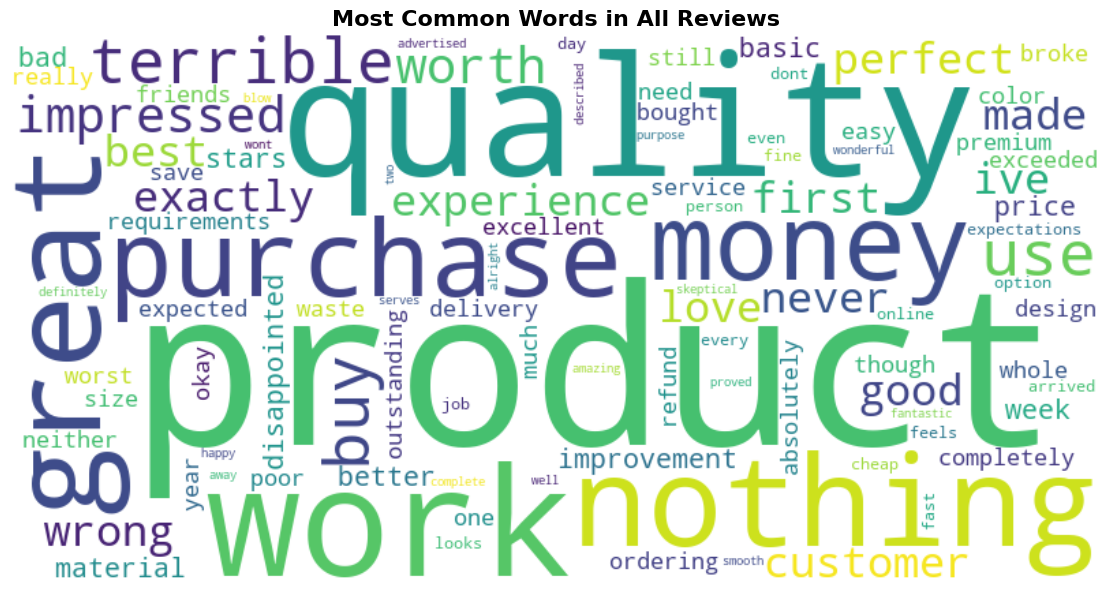

In [18]:
all_text = ' '.join(df['no_stopwords'])

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100,
    colormap='viridis',
    collocations=False
).generate(all_text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in All Reviews', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()

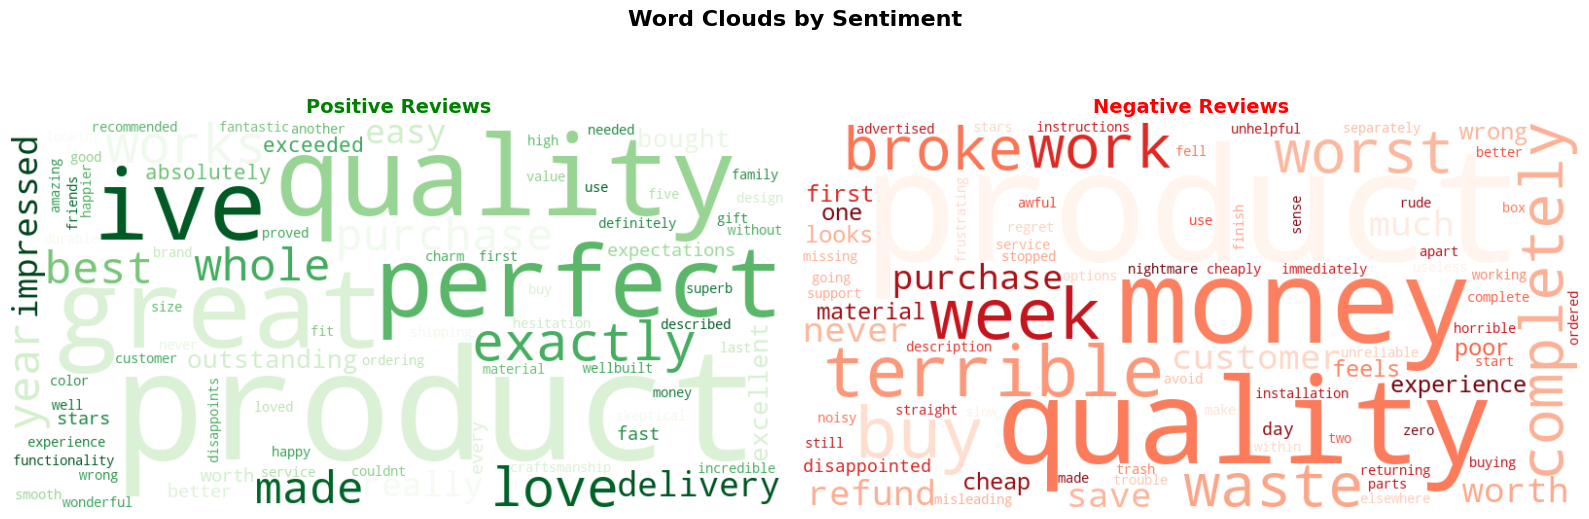

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pos_text = ' '.join(df[df['sentiment_label']=='Positive']['no_stopwords'])
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=80, collocations=False).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews', fontsize=14, fontweight='bold', color='green')


neg_text = ' '.join(df[df['sentiment_label']=='Negative']['no_stopwords'])
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=80, collocations=False).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews', fontsize=14, fontweight='bold', color='red')

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_wordcloud_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


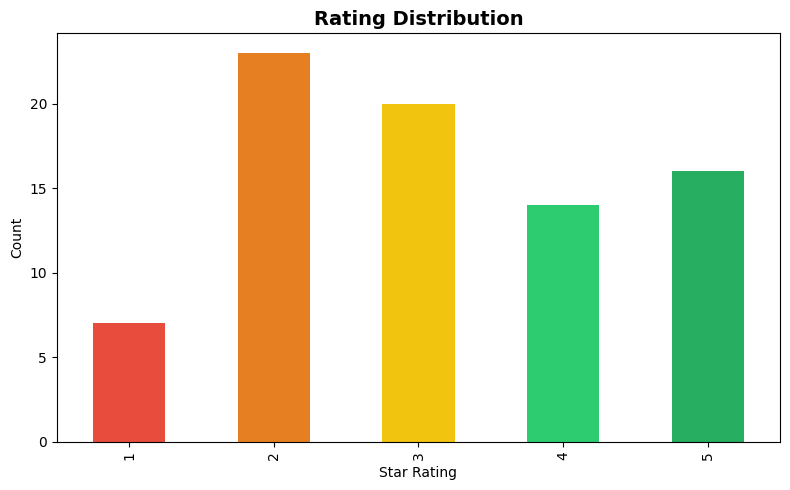

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
df['rating'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'], ax=ax)
ax.set_title('Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('03_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

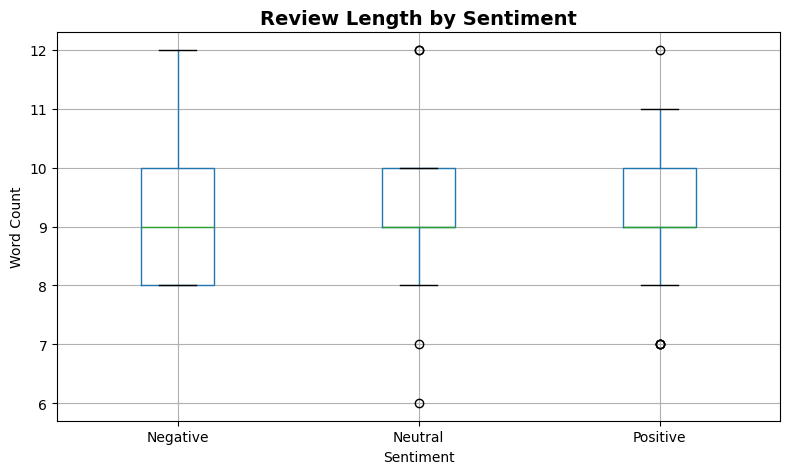

In [22]:
df['word_count'] = df['review_text'].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='word_count', by='sentiment_label', ax=ax)
ax.set_title('Review Length by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Word Count')
plt.suptitle('')
plt.tight_layout()
plt.savefig('04_review_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
def get_textblob_sentiment(text):
    """Get sentiment polarity using TextBlob."""
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

df['textblob_score'] = df['review_text'].apply(get_textblob_sentiment)
df['textblob_label'] = df['textblob_score'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

print("TextBlob Sentiment Examples:")
for _, row in df.head(5).iterrows():
    print(f"  Score: {row['textblob_score']:+.2f} | Label: {row['textblob_label']:8s} | {row['review_text'][:60]}...")

TextBlob Sentiment Examples:
  Score: -1.00 | Label: Negative | Terrible quality. Broke after just two days of use....
  Score: +0.88 | Label: Positive | This product is amazing! Best purchase I've made this year....
  Score: +0.30 | Label: Positive | The whole experience from ordering to delivery was smooth....
  Score: -0.05 | Label: Neutral  | Complete waste of money. Does not work as advertised....
  Score: +0.62 | Label: Positive | The color and size were perfect. Exactly as described....


In [24]:
vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get compound sentiment score using VADER."""
    scores = vader.polarity_scores(text)
    return scores['compound']  # Combined score from -1 to +1

df['vader_score'] = df['review_text'].apply(get_vader_sentiment)
df['vader_label'] = df['vader_score'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)

print("\nVADER Sentiment Examples:")
for _, row in df.head(5).iterrows():
    print(f"  Score: {row['vader_score']:+.3f} | Label: {row['vader_label']:8s} | {row['review_text'][:60]}...")


VADER Sentiment Examples:
  Score: -0.710 | Label: Negative | Terrible quality. Broke after just two days of use....
  Score: +0.852 | Label: Positive | This product is amazing! Best purchase I've made this year....
  Score: +0.000 | Label: Neutral  | The whole experience from ordering to delivery was smooth....
  Score: -0.421 | Label: Negative | Complete waste of money. Does not work as advertised....
  Score: +0.572 | Label: Positive | The color and size were perfect. Exactly as described....


In [25]:
from sklearn.metrics import accuracy_score, classification_report

print("\n--- TextBlob Accuracy ---")
print(f"Accuracy: {accuracy_score(df['sentiment_label'], df['textblob_label']):.2%}")
print(classification_report(df['sentiment_label'], df['textblob_label']))

print("--- VADER Accuracy ---")
print(f"Accuracy: {accuracy_score(df['sentiment_label'], df['vader_label']):.2%}")
print(classification_report(df['sentiment_label'], df['vader_label']))


--- TextBlob Accuracy ---
Accuracy: 68.75%
              precision    recall  f1-score   support

    Negative       0.90      0.60      0.72        30
     Neutral       0.52      0.60      0.56        20
    Positive       0.68      0.83      0.75        30

    accuracy                           0.69        80
   macro avg       0.70      0.68      0.67        80
weighted avg       0.72      0.69      0.69        80

--- VADER Accuracy ---
Accuracy: 65.00%
              precision    recall  f1-score   support

    Negative       0.81      0.83      0.82        30
     Neutral       0.38      0.15      0.21        20
    Positive       0.59      0.80      0.68        30

    accuracy                           0.65        80
   macro avg       0.59      0.59      0.57        80
weighted avg       0.62      0.65      0.61        80



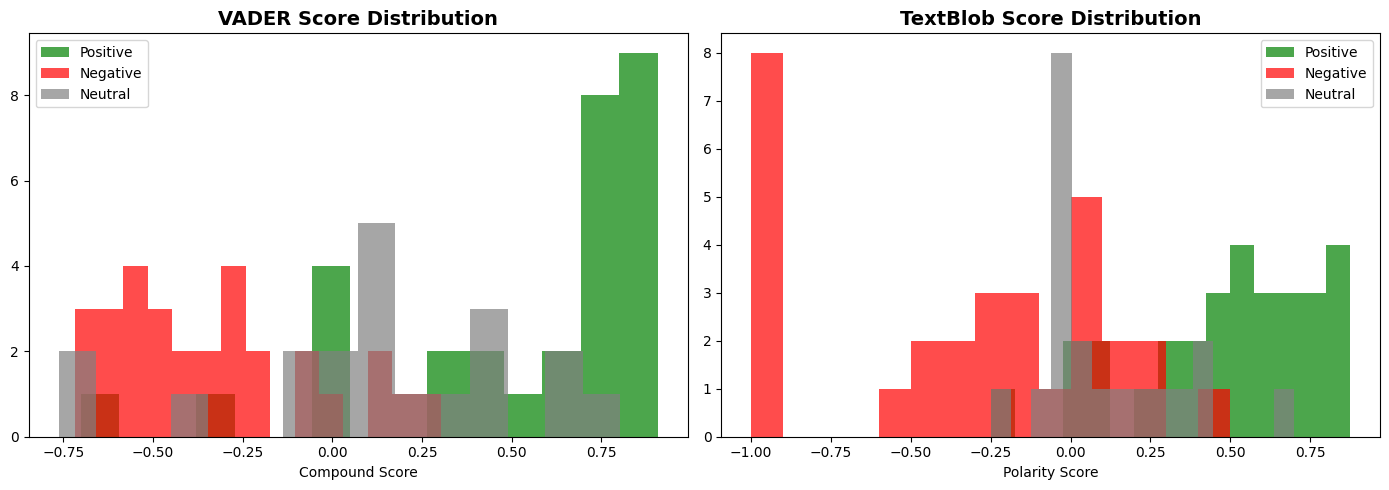

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['sentiment_label']=='Positive']['vader_score'], bins=15, alpha=0.7, color='green', label='Positive')
axes[0].hist(df[df['sentiment_label']=='Negative']['vader_score'], bins=15, alpha=0.7, color='red', label='Negative')
axes[0].hist(df[df['sentiment_label']=='Neutral']['vader_score'], bins=15, alpha=0.7, color='gray', label='Neutral')
axes[0].set_title('VADER Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].legend()

axes[1].hist(df[df['sentiment_label']=='Positive']['textblob_score'], bins=15, alpha=0.7, color='green', label='Positive')
axes[1].hist(df[df['sentiment_label']=='Negative']['textblob_score'], bins=15, alpha=0.7, color='red', label='Negative')
axes[1].hist(df[df['sentiment_label']=='Neutral']['textblob_score'], bins=15, alpha=0.7, color='gray', label='Neutral')
axes[1].set_title('TextBlob Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Polarity Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('05_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
count_vec = CountVectorizer(max_features=20, stop_words='english')
bow_matrix = count_vec.fit_transform(df['clean_text'])

print("Bag of Words vocabulary (top 20 words):")
print(count_vec.get_feature_names_out())
print(f"\nMatrix shape: {bow_matrix.shape}")
print("(80 reviews × 20 unique words)")
print(f"\nFirst review as numbers:\n{bow_matrix[0].toarray()}")

Bag of Words vocabulary (top 20 words):
['buy' 'customer' 'disappointed' 'does' 'good' 'great' 'impressed' 'ive'
 'like' 'material' 'money' 'perfect' 'price' 'product' 'purchase'
 'quality' 'terrible' 'use' 'works' 'worth']

Matrix shape: (80, 20)
(80 reviews × 20 unique words)

First review as numbers:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0]]


In [30]:
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

print(f"\nTF-IDF Matrix shape: {tfidf_matrix.shape}")
print("(80 reviews × 500 features including bigrams)")


TF-IDF Matrix shape: (80, 500)
(80 reviews × 500 features including bigrams)


In [32]:
feature_names = tfidf.get_feature_names_out()

for sentiment in ['Positive', 'Negative', 'Neutral']:
    mask = (df['sentiment_label'] == sentiment).values
    mean_tfidf = tfidf_matrix[mask].mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    
    print(f"\nTop 10 TF-IDF words for {sentiment} reviews:")
    for idx in top_indices:
        print(f"  {feature_names[idx]}: {mean_tfidf[idx]:.3f}")


Top 10 TF-IDF words for Positive reviews:
  product: 0.058
  great: 0.035
  quality: 0.030
  exactly: 0.030
  ive: 0.030
  perfect: 0.028
  stars: 0.027
  really: 0.026
  expectations: 0.025
  exceeded: 0.025

Top 10 TF-IDF words for Negative reviews:
  product: 0.047
  money: 0.037
  wrong: 0.031
  buy: 0.030
  terrible: 0.028
  quality: 0.027
  refund: 0.027
  customer: 0.026
  like: 0.026
  item: 0.025

Top 10 TF-IDF words for Neutral reviews:
  works: 0.062
  product: 0.049
  basic: 0.048
  product works: 0.045
  bad: 0.042
  expected: 0.041
  quality: 0.036
  impressed: 0.033
  okay: 0.032
  use: 0.032


In [33]:
X = tfidf_matrix
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} reviews")
print(f"Test set:     {X_test.shape[0]} reviews")
print(f"\nTraining distribution:")
print(y_train.value_counts())



Training set: 60 reviews
Test set:     20 reviews

Training distribution:
sentiment_label
Positive    23
Negative    22
Neutral     15
Name: count, dtype: int64


In [34]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("\n--- ML Classification Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))


--- ML Classification Results ---
Accuracy: 45.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.38      0.46         8
     Neutral       0.00      0.00      0.00         5
    Positive       0.40      0.86      0.55         7

    accuracy                           0.45        20
   macro avg       0.33      0.41      0.34        20
weighted avg       0.38      0.45      0.38        20



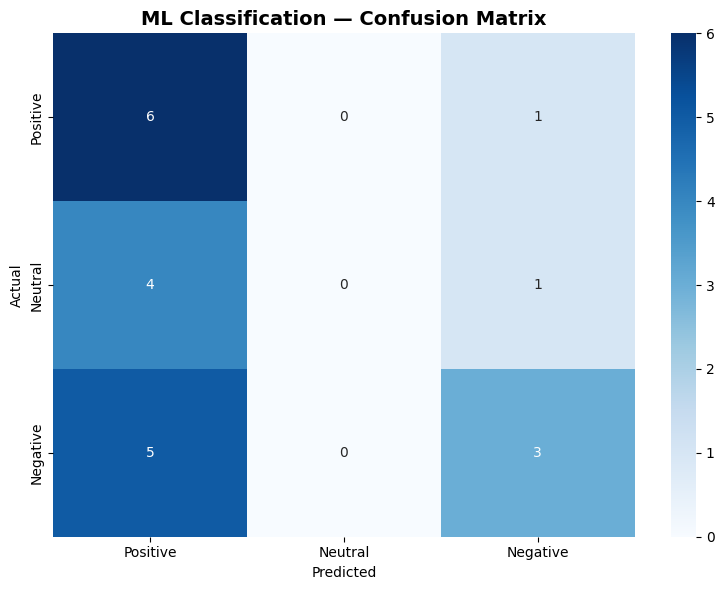

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Neutral', 'Negative'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'], ax=ax)
ax.set_title('ML Classification — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('06_ml_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


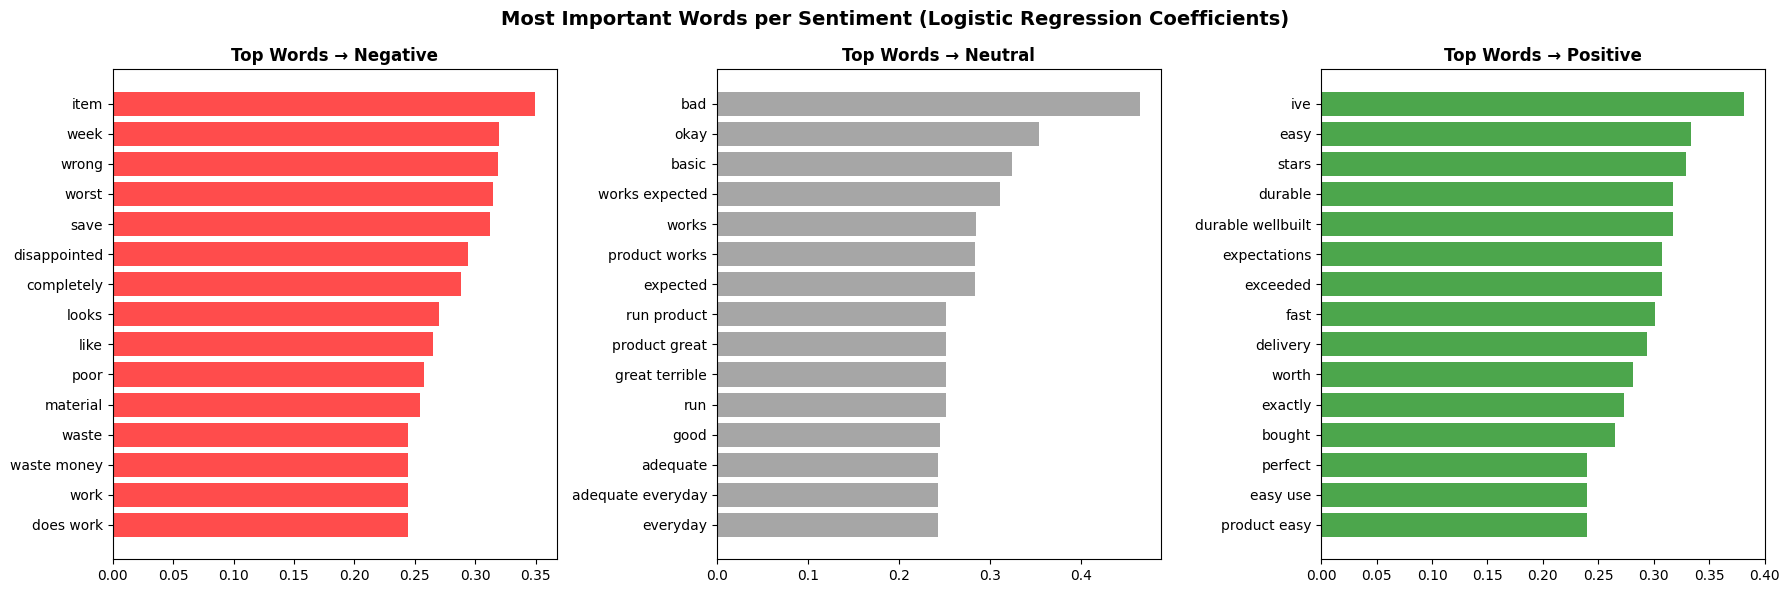

In [36]:
feature_names = tfidf.get_feature_names_out()
classes = lr_model.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (cls, ax) in enumerate(zip(classes, axes)):
    coefficients = lr_model.coef_[i]
    top_indices = coefficients.argsort()[-15:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    top_scores = [coefficients[j] for j in top_indices]
    
    colors = ['green' if cls == 'Positive' else 'red' if cls == 'Negative' else 'gray']
    ax.barh(range(len(top_words)), top_scores, color=colors[0], alpha=0.7)
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words)
    ax.set_title(f'Top Words → {cls}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Most Important Words per Sentiment (Logistic Regression Coefficients)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_important_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
def get_ngrams(text_series, n=2, top_k=15):
    """Extract top n-grams from a series of texts."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english')
    ngram_matrix = vec.fit_transform(text_series)
    freqs = ngram_matrix.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top_indices = freqs.argsort()[-top_k:][::-1]
    return [(vocab[i], freqs[i]) for i in top_indices]

print("Top 15 Bigrams in POSITIVE reviews:")
for phrase, count in get_ngrams(df[df['sentiment_label']=='Positive']['clean_text']):
    print(f"  '{phrase}': {count:.0f}")

print("\nTop 15 Bigrams in NEGATIVE reviews:")
for phrase, count in get_ngrams(df[df['sentiment_label']=='Negative']['clean_text']):
    print(f"  '{phrase}': {count:.0f}")

Top 15 Bigrams in POSITIVE reviews:
  'worth penny': 1
  'worth dollar': 1
  'works perfectly': 1
  'works like': 1
  'works flawlessly': 1
  'wonderful product': 1
  'welldesigned product': 1
  'wellbuilt years': 1
  'way better': 1
  'value money': 1
  'using month': 1
  'totally worth': 1
  'thing ive': 1
  'superb quality': 1
  'super fast': 1

Top 15 Bigrams in NEGATIVE reviews:
  'waste money': 2
  'does work': 2
  'wrong item': 1
  'worth money': 1
  'wrong despite': 1
  'worst purchase': 1
  'worst product': 1
  'work total': 1
  'working week': 1
  'work advertised': 1
  'weeks arrive': 1
  'week frustrating': 1
  'zero stars': 1
  'wash poor': 1
  'waiting refund': 1


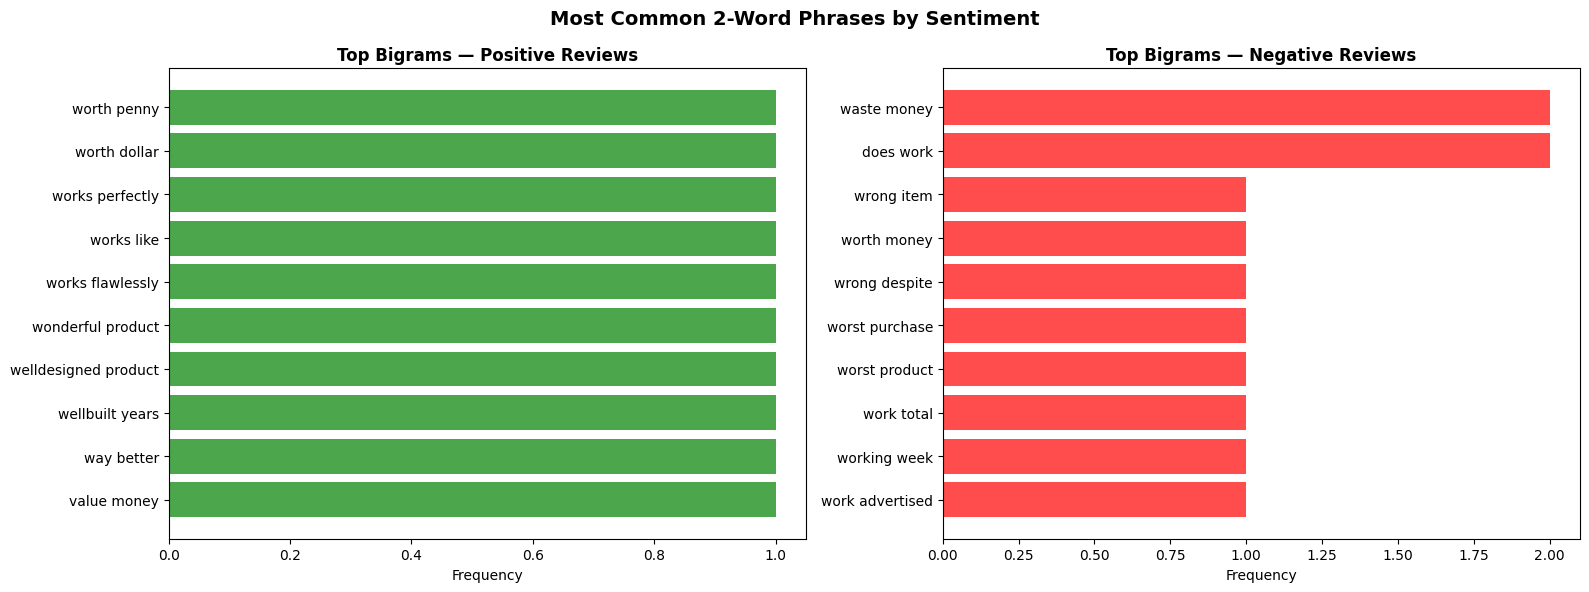

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (sentiment, color) in enumerate([('Positive', 'green'), ('Negative', 'red')]):
    bigrams = get_ngrams(df[df['sentiment_label']==sentiment]['clean_text'], n=2, top_k=10)
    phrases = [b[0] for b in bigrams]
    counts = [b[1] for b in bigrams]
    
    axes[i].barh(phrases, counts, color=color, alpha=0.7)
    axes[i].set_title(f'Top Bigrams — {sentiment} Reviews', fontsize=12, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Frequency')

plt.suptitle('Most Common 2-Word Phrases by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
new_reviews = [
    "This is the best product I have ever used! Absolutely fantastic!",
    "Terrible experience. Product broke immediately. Want my money back.",
    "It's okay, nothing special. Works fine for basic use.",
    "I love everything about this. Perfect quality and fast delivery!",
    "Completely useless. Worst purchase of my life. Total waste.",
]

new_tfidf = tfidf.transform([clean_text(r) for r in new_reviews])
new_predictions = lr_model.predict(new_tfidf)
new_probabilities = lr_model.predict_proba(new_tfidf)

print("\n--- Predictions on New Reviews ---\n")
for review, pred, proba in zip(new_reviews, new_predictions, new_probabilities):
    vader_score = get_vader_sentiment(review)
    max_prob = max(proba) * 100
    print(f"Review: \"{review[:70]}...\"")
    print(f"  ML Prediction: {pred} ({max_prob:.0f}% confidence)")
    print(f"  VADER Score:   {vader_score:+.3f}")
    print()



--- Predictions on New Reviews ---

Review: "This is the best product I have ever used! Absolutely fantastic!..."
  ML Prediction: Positive (51% confidence)
  VADER Score:   +0.865

Review: "Terrible experience. Product broke immediately. Want my money back...."
  ML Prediction: Negative (48% confidence)
  VADER Score:   -0.681

Review: "It's okay, nothing special. Works fine for basic use...."
  ML Prediction: Neutral (44% confidence)
  VADER Score:   -0.238

Review: "I love everything about this. Perfect quality and fast delivery!..."
  ML Prediction: Positive (56% confidence)
  VADER Score:   +0.871

Review: "Completely useless. Worst purchase of my life. Total waste...."
  ML Prediction: Negative (56% confidence)
  VADER Score:   -0.890



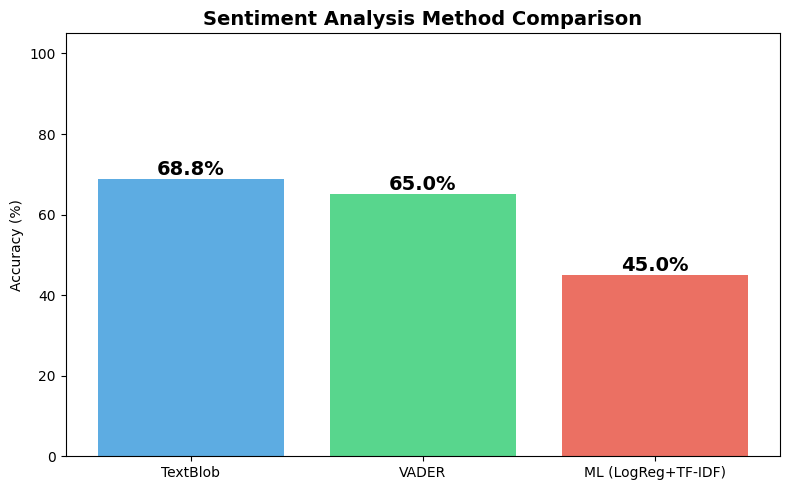

In [40]:
methods = ['TextBlob', 'VADER', 'ML (LogReg+TF-IDF)']
accuracies = [
    accuracy_score(df['sentiment_label'], df['textblob_label']),
    accuracy_score(df['sentiment_label'], df['vader_label']),
    accuracy_score(y_test, y_pred)
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, [a*100 for a in accuracies],
              color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.8)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1%}', ha='center', fontsize=14, fontweight='bold')
ax.set_title('Sentiment Analysis Method Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('09_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
print("\n" + "=" * 70)
print("     PROJECT 6 COMPLETE — NLP SENTIMENT ANALYSIS")
print("=" * 70)
print("""
NLP CONCEPTS COVERED:
  ✅ Text preprocessing (lowercase, punctuation, stopwords)
  ✅ Tokenization (splitting text into words)
  ✅ Stopword removal (removing filler words)
  ✅ Word frequency analysis (Counter)
  ✅ Word clouds (visual word frequency)
  ✅ TextBlob sentiment (dictionary-based, simple)
  ✅ VADER sentiment (handles negation, intensity, social media)
  ✅ Bag of Words (CountVectorizer — text to numbers)
  ✅ TF-IDF (weighted text to numbers — unique words score higher)
  ✅ ML text classification (Logistic Regression + TF-IDF)
  ✅ N-grams (bigrams capture 2-word phrases like "not good")
  ✅ Model comparison (TextBlob vs VADER vs ML)
  ✅ Prediction on new unseen reviews

CHARTS GENERATED:
  01 — Word cloud (all reviews)
  02 — Word clouds by sentiment (positive vs negative)
  03 — Rating distribution
  04 — Review length by sentiment
  05 — Sentiment score distributions (VADER vs TextBlob)
  06 — ML confusion matrix
  07 — Most important words per sentiment class
  08 — Top bigrams by sentiment
  09 — Method comparison (accuracy bar chart)

KEY INTERVIEW TAKEAWAYS:
  • Text → numbers: TF-IDF is the standard method
  • TF-IDF > Bag of Words because it weighs unique words higher
  • VADER > TextBlob for reviews/social media (handles negation, caps)
  • ML (LogReg+TF-IDF) > rule-based for custom datasets
  • N-grams capture context that single words miss
  • Same models (LogReg) work for text AND tabular data!
""")
print("=" * 70)


     PROJECT 6 COMPLETE — NLP SENTIMENT ANALYSIS

NLP CONCEPTS COVERED:
  ✅ Text preprocessing (lowercase, punctuation, stopwords)
  ✅ Tokenization (splitting text into words)
  ✅ Stopword removal (removing filler words)
  ✅ Word frequency analysis (Counter)
  ✅ Word clouds (visual word frequency)
  ✅ TextBlob sentiment (dictionary-based, simple)
  ✅ VADER sentiment (handles negation, intensity, social media)
  ✅ Bag of Words (CountVectorizer — text to numbers)
  ✅ TF-IDF (weighted text to numbers — unique words score higher)
  ✅ ML text classification (Logistic Regression + TF-IDF)
  ✅ N-grams (bigrams capture 2-word phrases like "not good")
  ✅ Model comparison (TextBlob vs VADER vs ML)
  ✅ Prediction on new unseen reviews

CHARTS GENERATED:
  01 — Word cloud (all reviews)
  02 — Word clouds by sentiment (positive vs negative)
  03 — Rating distribution
  04 — Review length by sentiment
  05 — Sentiment score distributions (VADER vs TextBlob)
  06 — ML confusion matrix
  07 — Most i